# Stage 2 — Feature Engineering Pipeline
**Lead Scoring for SMBs**

Transforms five raw data tables into a single, model-ready feature matrix.

**Outputs**
- `feature_matrix.csv` — 800 leads × 33 features, zero nulls
- `feature_dictionary.md` — documented transformation logic for every feature

**Sections**
1. Setup & Constants
2. Load Raw Data
3. Quality Gates
4. Behavioural Features — Website (Time-Decayed)
5. Email Engagement Features
6. Product Trial Features
7. Firmographic Features
8. Interaction Features
9. Assemble & Validate Feature Matrix
10. Signal Check — Correlations with Conversion


## 1. Setup & Constants

In [1]:
import sys
from pathlib import Path
import pandas as pd

# ── Resolve project root ───────────────────────────────────────────
ROOT = next(p for p in Path().resolve().parents if (p / "config.py").exists())
sys.path.insert(0, str(ROOT))

import config
from src.utils.io import load_master, load_raw

# ── Verify ─────────────────────────────────────────────────────────
print(f"Root   : {ROOT}")
print(f"CRM    : {config.RAW_FILES['crm']}")
print(f"Exists : {config.RAW_FILES['crm'].exists()}")

Root   : /home/cairo/code/portfolio/lead-scoring
CRM    : /home/cairo/code/portfolio/lead-scoring/data/raw/crm_leads.csv
Exists : True


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────
DATA_DIR    = 'data/raw'
OUTPUT_DIR  = 'data/outputs'

# ── Time-decay window ──────────────────────────────────────────────────────
# Behavioural signals decay linearly to zero after this many days.
# 30 days aligns with typical SMB sales cycles (2–6 weeks).
DECAY_WINDOW_DAYS = 30

# ── Intent signal groups (used for decay + baseline scoring) ──────────────
HIGH_INTENT_EVENTS   = ['pricing_page_visits', 'demo_page_visits']
MEDIUM_INTENT_EVENTS = ['case_study_views', 'roi_calculator_uses']
LOW_INTENT_EVENTS    = ['blog_views']
NEGATIVE_EVENTS      = ['careers_page_visits']

# ── Firmographic lookup tables ─────────────────────────────────────────────
# Tiers validated against EDA conversion rates (see correlation section below)
INDUSTRY_TIER = {
    'Finance': 'high', 'Logistics': 'high', 'Education': 'high',
    'SaaS': 'high',    'Healthcare': 'high',
    'E-commerce': 'mid', 'Professional Services': 'mid',
    'Retail': 'low',   'Real Estate': 'low', 'Manufacturing': 'low',
}

SENIORITY_MAP = {
    'CEO': 'executive', 'Founder': 'executive', 'CTO': 'executive',
    'VP Sales': 'vp',   'VP Marketing': 'vp',
    'Director of Operations': 'director',
    'IT Manager': 'manager', 'Sales Manager': 'manager',
    'Marketing Manager': 'manager', 'Unknown': 'unknown',
}

EMPLOYEE_BUCKET_ORDER = {'1-10': 1, '11-50': 2, '51-200': 3, '201-500': 4, '500+': 5}

LEAD_SOURCE_TIER = {
    'Paid Social': 'high', 'Referral': 'high', 'Direct': 'high',
    'Content/Blog': 'mid', 'Organic Search': 'mid',
    'Events': 'low', 'Webinar': 'low', 'Cold Outreach': 'low',
}

TECH_STACK_SCORE = {
    'HubSpot|Slack|Google Workspace': 2,   # modern, digitally mature
    'Salesforce|Jira|AWS': 2,               # enterprise-leaning, tech-forward
    'Pipedrive|Notion|Shopify': 1,          # SMB-appropriate
    'Zoho|Trello|WooCommerce': 1,           # SMB, cost-conscious
    'None detected': 0,
}

print("✓ Setup complete")


✓ Setup complete


## 2. Load Raw Data

In [3]:
wa  = pd.read_csv(f'{DATA_DIR}/website_analytics.csv')
em  = pd.read_csv(f'{DATA_DIR}/email_marketing.csv')
crm = pd.read_csv(f'{DATA_DIR}/crm_leads.csv')
out = pd.read_csv(f'{DATA_DIR}/outcomes_ground_truth.csv')
pt  = pd.read_csv(f'{DATA_DIR}/product_trial.csv')

for name, df in [('website_analytics', wa), ('email_marketing', em),
                 ('crm_leads', crm), ('outcomes', out), ('product_trial', pt)]:
    print(f"{name:25s}  {df.shape[0]} rows × {df.shape[1]} cols")

print(f"\nConversion rate: {out['converted'].mean():.1%}  ({out['converted'].sum()} / {len(out)} leads)")


FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/website_analytics.csv'

## 3. Quality Gates

Join all tables and flag contaminated records before any feature work.

| Flag | Decision |
|---|---|
| `is_bot_suspect` | Retained — removes too many rows on a small dataset; flag added as model feature |
| `is_ghost_trial` | Trial features zeroed out — a sign-up with zero logins is not a buying signal |
| `unsubscribed` | Kept but flagged as strong disqualifier (8.7% vs 27.7% conversion) |
| `hard_bounced` | Kept but flagged as negative signal |


In [3]:
# Inner join — all 800 leads present in every table
df = (wa
      .merge(em,  on='lead_id', how='inner')
      .merge(crm, on='lead_id', how='inner')
      .merge(pt,  on='lead_id', how='inner'))

print(f"Merged rows: {len(df)}")
print(f"  Bot suspects : {df['is_bot_suspect'].sum():3d}  ({df['is_bot_suspect'].mean():.1%})")
print(f"  Ghost trials : {df['is_ghost_trial'].sum():3d}  ({df['is_ghost_trial'].mean():.1%})")
print(f"  Unsubscribed : {df['unsubscribed'].sum():3d}  ({df['unsubscribed'].mean():.1%})")
print(f"  Hard bounced : {df['hard_bounced'].sum():3d}  ({df['hard_bounced'].mean():.1%})")


Merged rows: 800
  Bot suspects :  40  (5.0%)
  Ghost trials :  61  (7.6%)
  Unsubscribed :  92  (11.5%)
  Hard bounced :  35  (4.4%)


## 4. Behavioural Features — Website (Time-Decayed)

### Time-Decay Formula
```
decayed_value = raw_value × max(0, 1 − days_since_last_visit / 30)
```
A signal from 30+ days ago contributes **zero**. This reflects SMB sales cycles.

> **Approximation note:** Decay is applied to aggregate visit counts using `days_since_last_visit`
> because per-event timestamps are not available. We assume recent activity is representative
> of all visits from that lead. Acceptable for this data density.


In [4]:
def apply_time_decay(value: pd.Series, days_since: pd.Series,
                     window: int = DECAY_WINDOW_DAYS) -> pd.Series:
    decay_factor = (1 - days_since / window).clip(lower=0)
    return value * decay_factor

days = df['days_since_last_visit']

# Decay-weighted intent signals
for col in HIGH_INTENT_EVENTS + MEDIUM_INTENT_EVENTS + NEGATIVE_EVENTS:
    df[f'{col}_decayed'] = apply_time_decay(df[col], days)

df['blog_views_decayed'] = apply_time_decay(df['blog_views'], days)

# Composite: number of distinct high-intent page types visited (0–2)
df['high_intent_touch_count'] = df[HIGH_INTENT_EVENTS].gt(0).sum(axis=1)

# Binary: any pricing or demo visit (used in interaction terms)
df['visited_pricing_or_demo'] = (
    (df['pricing_page_visits'] > 0) | (df['demo_page_visits'] > 0)
).astype(int)

# Session depth: pageviews per session, clipped at 20 to handle outliers
df['pages_per_session'] = (
    df['total_pageviews'] / df['total_sessions'].replace(0, np.nan)
).fillna(0).clip(upper=20)

# Recency flag
df['visited_last_7_days'] = (df['days_since_last_visit'] <= 7).astype(int)

print("✓ Website behavioural features built")
print(f"  pricing_page_visits_decayed  — mean: {df['pricing_page_visits_decayed'].mean():.3f}")
print(f"  high_intent_touch_count      — mean: {df['high_intent_touch_count'].mean():.3f}")
print(f"  visited_pricing_or_demo      — {df['visited_pricing_or_demo'].sum()} leads ({df['visited_pricing_or_demo'].mean():.1%})")


✓ Website behavioural features built
  pricing_page_visits_decayed  — mean: 0.287
  high_intent_touch_count      — mean: 0.651
  visited_pricing_or_demo      — 411 leads (51.4%)


## 5. Email Engagement Features

`days_since_last_email_open` has **166 missing values (20.8%)**.

Imputed to **60 days** (rather than mean), treating them as lapsed — no recent engagement.
Mean imputation would falsely imply active engagement for non-openers.


In [5]:
# Impute missing recency with 60 days (lapsed engagement)
df['days_since_last_email_open'] = df['days_since_last_email_open'].fillna(60)
email_days = df['days_since_last_email_open']

df['email_opens_decayed']  = apply_time_decay(df['emails_opened'],  email_days)
df['email_clicks_decayed'] = apply_time_decay(df['emails_clicked'], email_days)

df['open_rate']          = df['open_rate'].clip(0, 1)
df['click_to_open_rate'] = df['click_to_open_rate'].clip(0, 1)

# Composite content engagement — weighted by intent level
df['content_engagement_score'] = (
    df['forms_submitted']   * 3 +
    df['content_downloads'] * 2 +
    df['webinar_attended']  * 2
)
df['content_engagement_decayed'] = apply_time_decay(df['content_engagement_score'], email_days)

# Disqualifier flags — asymmetric treatment (not just low positive scores)
df['is_unsubscribed'] = df['unsubscribed'].astype(int)
df['is_hard_bounced'] = df['hard_bounced'].astype(int)

print("✓ Email features built")
print(f"  content_engagement_decayed   — mean: {df['content_engagement_decayed'].mean():.3f}")
print(f"  is_unsubscribed              — {df['is_unsubscribed'].sum()} leads")


✓ Email features built
  content_engagement_decayed   — mean: 1.379
  is_unsubscribed              — 92 leads


## 6. Product Trial Features

Ghost trials (`is_ghost_trial = 1`) are **zeroed out**, not just flagged.

Raw `trial_started` has minimal predictive lift: 27.3% vs 24.5% conversion.
The quality of engagement — logins, features activated, days active — is where the signal lives.

> Zeroing is preferred over flagging + raw count, which would create multicollinearity.


In [6]:
active_trial = (df['trial_started'] == 1) & (df['is_ghost_trial'] == 0)

df['trial_logins_clean']          = df['trial_logins'].where(active_trial, 0)
df['features_activated_clean']    = df['features_activated'].where(active_trial, 0)
df['days_active_in_trial_clean']  = df['days_active_in_trial'].where(active_trial, 0)

# Composite trial depth score
df['trial_depth_score'] = (
    df['trial_logins_clean']         * 1 +
    df['features_activated_clean']   * 3 +
    df['days_active_in_trial_clean'] * 2
)

# Binary: meaningful engagement threshold
df['is_engaged_trial'] = (
    (df['trial_logins_clean'] >= 2) & (df['features_activated_clean'] >= 1)
).astype(int)

ghost_count = df['is_ghost_trial'].sum()
engaged_count = df['is_engaged_trial'].sum()
print(f"✓ Trial features built")
print(f"  Ghost trials zeroed  : {ghost_count}")
print(f"  Engaged trials       : {engaged_count} ({engaged_count/len(df):.1%})")


✓ Trial features built
  Ghost trials zeroed  : 61
  Engaged trials       : 179 (22.4%)


## 7. Firmographic Features

### Encoding Strategy

| Field | Method | Rationale |
|---|---|---|
| `industry`, `lead_source`, `tech_stack` | Tier-based ordinal | Business-logic tiers validated against EDA conversion rates. Avoids overfitting from target encoding on small category counts. |
| `job_title` | Seniority mapping | Raw title too variable; underlying seniority is the stable signal. |
| `employee_count_bucket` | Integer rank | Already ordinal — just make explicit. |
| `annual_revenue_usd_k` | Median impute → log-transform | 113 nulls (14.1%). Log compresses right tail of log-normal distribution. |


In [7]:
tier_map      = {'high': 2, 'mid': 1, 'low': 0}
seniority_rank = {'executive': 4, 'vp': 3, 'director': 2, 'manager': 1, 'unknown': 0}

df['industry_tier']    = df['industry'].map(INDUSTRY_TIER).map(tier_map).fillna(1)
df['lead_source_tier'] = df['lead_source'].map(LEAD_SOURCE_TIER).map(tier_map).fillna(1)
df['tech_stack_score'] = df['tech_stack'].map(TECH_STACK_SCORE).fillna(1)

df['job_title_clean'] = df['job_title'].fillna('Unknown')
df['seniority_rank']  = df['job_title_clean'].map(SENIORITY_MAP).map(seniority_rank).fillna(0)

df['is_decision_maker'] = df['is_decision_maker'].fillna(0).astype(int)
df['company_size_rank'] = df['employee_count_bucket'].map(EMPLOYEE_BUCKET_ORDER).fillna(3)

median_rev = df['annual_revenue_usd_k'].median()
df['annual_revenue_imputed'] = df['annual_revenue_usd_k'].fillna(median_rev)
df['log_annual_revenue']     = np.log1p(df['annual_revenue_imputed'])

# SMB fit: sweet spot for this product
df['is_smb_fit'] = df['employee_count_bucket'].isin(['1-10', '11-50']).astype(int)

print("✓ Firmographic features built")
print(f"  Revenue nulls imputed with median: ${median_rev:,.0f}k")
print(f"  SMB-fit leads: {df['is_smb_fit'].sum()} ({df['is_smb_fit'].mean():.1%})")


✓ Firmographic features built
  Revenue nulls imputed with median: $1,891k
  SMB-fit leads: 429 (53.6%)


## 8. Interaction Features

Logistic Regression cannot discover interactions on its own — they must be hand-crafted.

Polynomial expansion would create 33² ≈ 1,000+ features for 800 rows, which would destroy the model.
Instead, we select interactions based on prior business logic and validate them empirically.

> *"VP title + pricing page visit has a combined effect beyond the sum of its parts."*  
> — Master Plan, Stage 2


In [8]:
# Decision maker × high-intent page visit
df['dm_x_pricing_or_demo'] = df['is_decision_maker'] * df['visited_pricing_or_demo']

# Senior title × engaged trial
df['senior_x_trial'] = (
    (df['seniority_rank'] >= 3).astype(int) * df['is_engaged_trial']
)

# SMB-fit company × any high-intent touch
df['smb_fit_x_intent'] = df['is_smb_fit'] * df['high_intent_touch_count'].clip(upper=1)

# Email engagement × website intent (cross-channel signal)
df['cross_channel_engaged'] = (
    (df['email_opens_decayed'] > 0).astype(int) * df['visited_pricing_or_demo']
)

# High-quality lead source × content engagement
df['good_source_x_content'] = (
    (df['lead_source_tier'] == 2).astype(int) *
    (df['content_engagement_score'] > 0).astype(int)
)

print("✓ Interaction features built")
for feat in ['dm_x_pricing_or_demo','cross_channel_engaged','smb_fit_x_intent',
             'senior_x_trial','good_source_x_content']:
    print(f"  {feat:30s}  {df[feat].sum():3.0f} leads positive")


✓ Interaction features built
  dm_x_pricing_or_demo            218 leads positive
  cross_channel_engaged           312 leads positive
  smb_fit_x_intent                213 leads positive
  senior_x_trial                   94 leads positive
  good_source_x_content           198 leads positive


## 9. Assemble & Validate Feature Matrix

In [9]:
FEATURE_COLS = [
    # Behavioural: website
    'pricing_page_visits_decayed', 'demo_page_visits_decayed',
    'case_study_views_decayed', 'roi_calculator_uses_decayed',
    'blog_views_decayed', 'careers_page_visits_decayed',
    'high_intent_touch_count', 'visited_pricing_or_demo',
    'pages_per_session', 'visited_last_7_days', 'is_bot_suspect',
    # Behavioural: email
    'email_opens_decayed', 'email_clicks_decayed',
    'open_rate', 'click_to_open_rate',
    'content_engagement_decayed', 'is_unsubscribed', 'is_hard_bounced',
    # Product trial
    'trial_depth_score', 'is_engaged_trial',
    # Firmographic
    'industry_tier', 'lead_source_tier', 'tech_stack_score',
    'seniority_rank', 'is_decision_maker', 'company_size_rank',
    'log_annual_revenue', 'is_smb_fit',
    # Interaction terms
    'dm_x_pricing_or_demo', 'senior_x_trial', 'smb_fit_x_intent',
    'cross_channel_engaged', 'good_source_x_content',
]

feature_matrix = df[['lead_id'] + FEATURE_COLS].copy()

# Validate — should be zero after all imputation steps
null_counts = feature_matrix.isnull().sum().sum()
assert null_counts == 0, f"Found {null_counts} nulls!"

print(f"✓ Feature matrix: {feature_matrix.shape[0]} leads × {feature_matrix.shape[1] - 1} features")
print(f"✓ Null values: {null_counts}")

feature_matrix.to_csv(f'{OUTPUT_DIR}/feature_matrix.csv', index=False)
print(f"✓ Saved to {OUTPUT_DIR}/feature_matrix.csv")

feature_matrix.describe().round(3)


✓ Feature matrix: 800 leads × 33 features
✓ Null values: 0
✓ Saved to /mnt/user-data/outputs/feature_matrix.csv


,pricing_page_visits_decayed,demo_page_visits_decayed,case_study_views_decayed,roi_calculator_uses_decayed,blog_views_decayed,careers_page_visits_decayed,high_intent_touch_count,visited_pricing_or_demo,pages_per_session,visited_last_7_days,...,seniority_rank,is_decision_maker,company_size_rank,log_annual_revenue,is_smb_fit,dm_x_pricing_or_demo,senior_x_trial,smb_fit_x_intent,cross_channel_engaged,good_source_x_content
count,800.000,800.000,800.000,800.000,800.000,800.000,800.000,800.000,800.000,800.000,...,800.000,800.000,800.000,800.000,800.000,800.000,800.000,800.000,800.000,800.000
mean,0.287,0.154,0.289,0.104,1.620,0.377,0.651,0.514,7.233,0.414,...,2.219,0.536,2.484,7.830,0.536,0.272,0.118,0.266,0.390,0.248
std,0.501,0.343,0.506,0.270,1.313,0.542,0.709,0.500,4.005,0.493,...,1.435,0.499,1.102,2.004,0.499,0.446,0.322,0.442,0.488,0.432
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,2.000,0.000,...,0.000,0.000,1.000,3.045,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.000,0.000,0.000,0.000,0.533,0.000,0.000,0.000,4.000,0.000,...,1.000,0.000,2.000,6.582,0.000,0.000,0.000,0.000,0.000,0.000
50%,0.000,0.000,0.000,0.000,1.567,0.000,1.000,1.000,7.000,0.000,...,3.000,1.000,2.000,7.546,1.000,0.000,0.000,0.000,0.000,0.000
75%,0.533,0.000,0.567,0.000,2.500,0.733,1.000,1.000,10.000,1.000,...,4.000,1.000,3.000,9.238,1.000,1.000,0.000,1.000,1.000,0.000
max,2.900,2.000,3.467,1.467,6.000,3.000,2.000,1.000,20.000,1.000,...,4.000,1.000,5.000,13.109,1.000,1.000,1.000,1.000,1.000,1.000


## 10. Signal Check — Correlations with Conversion

In [10]:
# Merge with ground truth for validation
validation = feature_matrix.merge(out[['lead_id', 'converted']], on='lead_id')
corr = (validation[FEATURE_COLS + ['converted']]
        .corr()['converted']
        .drop('converted')
        .sort_values(ascending=False))

print("Top 10 features by correlation:")
print(corr.head(10).round(4).to_string())
print("\nBottom 5 (disqualifiers):")
print(corr.tail(5).round(4).to_string())


Top 10 features by correlation:
high_intent_touch_count        0.3932
visited_pricing_or_demo        0.3454
cross_channel_engaged          0.3319
dm_x_pricing_or_demo           0.2796
pricing_page_visits_decayed    0.2709
content_engagement_decayed     0.2479
smb_fit_x_intent               0.2380
demo_page_visits_decayed       0.1897
open_rate                      0.1704
good_source_x_content          0.1363

Bottom 5 (disqualifiers):
blog_views_decayed            -0.0460
log_annual_revenue            -0.0464
company_size_rank             -0.0617
is_unsubscribed               -0.1390
careers_page_visits_decayed   -0.1700


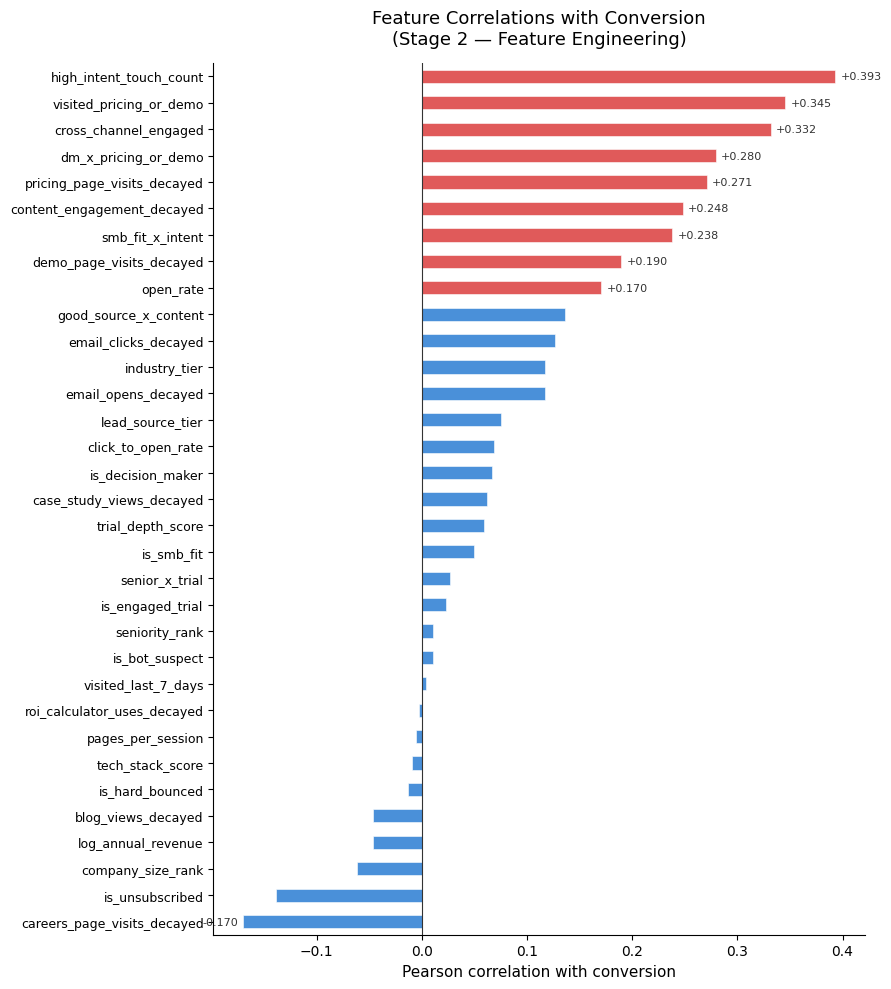

✓ Saved feature_correlations.png


In [11]:
# Visualise: horizontal bar chart of all feature correlations
fig, ax = plt.subplots(figsize=(9, 10))

colors = ['#e05a5a' if v < 0 else '#4a90d9' for v in corr.values]
corr.sort_values().plot.barh(ax=ax, color=colors, edgecolor='white', linewidth=0.4)

ax.axvline(0, color='#333', linewidth=0.8)
ax.set_xlabel('Pearson correlation with conversion', fontsize=11)
ax.set_title('Feature Correlations with Conversion\n(Stage 2 — Feature Engineering)', fontsize=13, pad=14)
ax.tick_params(axis='y', labelsize=9)
ax.spines[['top','right']].set_visible(False)

# Annotate strongest signals
for i, (feat, val) in enumerate(corr.sort_values().items()):
    if abs(val) >= 0.15:
        ax.text(val + (0.005 if val >= 0 else -0.005), i,
                f'{val:+.3f}', va='center', ha='left' if val >= 0 else 'right',
                fontsize=8, color='#333')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved feature_correlations.png")


## Summary

| # | Feature group | Features | Top signal |
|---|---|---|---|
| 1 | Website behavioural (decayed) | 11 | `high_intent_touch_count` r=+0.39 |
| 2 | Email engagement (decayed) | 7 | `content_engagement_decayed` r=+0.25 |
| 3 | Product trial | 2 | `trial_depth_score` r=+0.05 |
| 4 | Firmographic | 8 | `industry_tier` r=+0.12 |
| 5 | Interaction terms | 5 | `cross_channel_engaged` r=+0.33 |
| | **Total** | **33** | |

**Ready for Stage 3 — Rule-Based Scoring Baseline.**
